<a href="https://colab.research.google.com/github/kuzovkov/neural-university/blob/main/%D0%9F%D1%80%D0%BE%D0%B4%D0%B2%D0%B8%D0%BD%D1%83%D1%82%D1%8B%D0%B9_%D0%B1%D0%BB%D0%BE%D0%BA_%7C_%D0%92%D0%B0%D1%80%D0%B8%D0%B0%D1%86%D0%B8%D0%BE%D0%BD%D0%BD%D1%8B%D0%B5_%D0%B0%D0%B2%D1%82%D0%BE%D0%BA%D0%BE%D0%B4%D0%B8%D1%80%D0%BE%D0%B2%D1%89%D0%B8%D0%BA%D0%B8_(%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0)_%7C_%D0%A3%D0%98%D0%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Содержание темы**

1. [Теория](https://colab.research.google.com/drive/12pLBd2_WMVgu3wxMmfjQRf2WxldDDJzm?usp=sharing)

2. Практика





Перейдем к практической части урока по автокодировщикам. Обучим несколько сетей на изображениях рукописных цифр MNIST и исследуем их работу.


In [1]:
# Импортируем TensorFlow
import tensorflow as tf

In [2]:
# Импортируем Keras
import keras

In [3]:
# Подключим Numpy
import numpy as np

# Подключим библиотеку отображения графиков
import matplotlib.pyplot as plt

# Подключим датасет рукописных цифр MNIST
from tensorflow.keras.datasets import mnist

# Импортируем Keras
from tensorflow import keras

# Подключим все необходимые слои Keras
from tensorflow.keras.layers import Dense, Flatten, Reshape, Input, Lambda, LeakyReLU
from tensorflow.keras.layers import BatchNormalization, Dropout, concatenate, Conv2D, Conv2DTranspose

# Подключим модуль вычислений на Keras
import keras.backend as K

# Подключим модуль работы с операционной системой
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # От tensorflow будет получать только ошибки

In [4]:
# Загрузим датасет рукописных цифр
(xs_train, y_train), (xs_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
# Нормализация, приведем массивы пикселей к диапазону 0...1 для обучающей выборки
x_train = xs_train / 255.
x_test = xs_test / 255.

# Добавим 1 размерность numpy-массиву обучающей выборки
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test  = np.reshape(x_test,  (len(x_test),  28, 28, 1))

In [6]:
hidden_dim = 2  # Зададим размерность скрытого пространства AE

batch_size = 60 # Задамим размер батча для обучения AE(должно быть кратно 60 000)

In [7]:
# Определим функцию отображения результатов работы декодера

def showResult(decoder): # Получим обученный декодер

    n = 5
    total = 2*n+1                                                     # Считаем полное количесво выводимых цифр +1
    plt.figure(figsize=(total, total))                                # Создаем заготовку для финальной картинки
    num = 1                                                           # Счетчик выводимых цифр
    for i in range(-n, n+1):                                          # Цикл по горизонтали пространства Z
     for j in range(-n, n+1):                                         # Цикл по вертикали пространства Z
        ax = plt.subplot(total, total, num)                           # Добавим место для графика
        num += 1                                                      # Инкремент номера графика
        img = decoder.predict(np.expand_dims([3*i/n, 3*j/n], axis=0)) # Выполним предикт изображения цифры по точкам из Z области
        plt.imshow(img.squeeze(), cmap='gray')                        # Рисуем предсказанную цифру
        ax.get_xaxis().set_visible(False)                             # Спрячем ось X
        ax.get_yaxis().set_visible(False)                             # Спрячем ось Y

In [8]:
# Создадим функцию сборки блока построения сверточного энкодера

def encoderBlock(xin,        # Входной тензор
                 neu=8,      # Число нейроной сверточного слоя
                 kernel=3,   # Размер ядра сверточного слоя
                 strides=1): # Число шагом сверточного слоя

    # Составим блок сети
    x = Conv2D(neu, kernel_size=kernel, strides= strides, padding='same')(xin) # Добавим 2D свертку
    x = BatchNormalization()(x)                                                # Добавим нормализацию по батчу
    x = LeakyReLU()(x)                                                         # Добавим функцию активации

    # Вернем выходной тензор
    return x


In [9]:
# Создадим функцию сборки блока построения сверточного декодера

def decoderBlock(xin,        # Входной тензор
                 neu=8,      # Число нейроной сверточного слоя
                 kernel=3,   # Размер ядра сверточного слоя
                 strides=1): # Число шагом сверточного слоя

    # Составим блок сети
    x = Conv2DTranspose(neu, kernel_size=kernel, strides= strides, padding='same')(xin)  # Добавим обратную 2D свертку
    x = BatchNormalization()(x)                                                          # Добавим нормализацию по батчу
    x = LeakyReLU()(x)                                                                   # Добавим функцию активации

    # Вернем выходной тензор
    return x

## AE

### Простой AE

Напишем первый автокодировщик. Он состоит из двух частей – энкодера и декодера. Эти части создаем отдельно, затем из них конструируем AЕ. После обучения их можно будет использовать как вместе, так и раздельно.

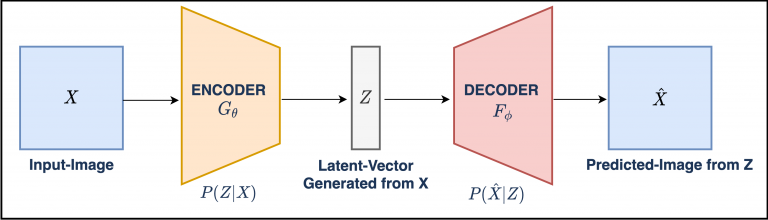

Давайте вспомним, что:
1. `Х` – пространство входных элементов, наш датасет.
2. `Z` – так называемое скрытое пространство. Это та область, где энкодер отображает входной датасет.
3. `X'`– это пространство восстановленных изображений. Его декодер создает из точек `Z`.

В дальнейшей работе мы будем придерживаться именно таких формулировок.

При изучении AE отдельно создаем нейронную сеть энкодера и отдельно – декодера. Затем собираем из них автокодировщик и обучаем его. При необходимости изучить скрытое пространство  берем обученный энкодер и прогоняем через него входной датасет, смотрим выход.

При необходимости генерировать картинки берем предобученный декодер и подаем ему на вход случайные выборки, смотрим на результаты. Возможно, нам потребуется оценить, как АЕ восстанавливает картинку по готовому образцу.

Вот и полная модель АЕ!

In [10]:
# Создадим энкодер

input_img = Input(shape=(28, 28, 1))       # Входной слой, размерность тензора 28х28х1
x = Flatten()(input_img)                   # Преобразуем 3d тензор в 1d размерностью 784
x = Dense(128, activation='relu')(x)       # Первый Dense
x = Dense(64, activation='relu')(x)        # Второй Dense
encoded = Dense(2, activation='linear')(x) # Выходной Dense

In [11]:
# Создадим декодер

input_enc = Input(shape=(2,))               # Входной слой декодера - размерность 2
d = Dense(64, activation='relu')(input_enc) # Первый Dense
d = Dense(28*28, activation='sigmoid')(d)   # Первый Dense  - 784 нейрона
decoded = Reshape((28, 28, 1))(d)           # Меняем размерность тензора на 28х28х1 - обратим внимание на размеры тензора на входе энкодера

In [12]:
# Собираем наши сетки

encoderAE = keras.Model(input_img, encoded, name="encoder")      # Собираем энкодер
decoderAE = keras.Model(input_enc, decoded, name="decoder")      # Собираем декодер

hidden = encoderAE(input_img)                                    # Энкодер отображает входные изображения в точки скрытого пространства
output = decoderAE(hidden)                                       # Декодер восстанавливает изображения  из точек скрытого пространства
autoencoder = keras.Model(input_img, output, name="autoencoder") # Собираем AE


Сборку автокодировщика можно записать в более компактной форме, без использования промежуточных переменных.


1. Записываем выход АЕ как результат работы декодера:

        output = decoderAE(hidden)

2. Декодер принимает на свой вход результат работы энкодера
        
        hidden = encoderAE(input_img)

3. Выражение п.2 подставим в выражение п.1. Итого на выходе AE получаем

        output = decoderAE(encoderAE(input_img))

4.  Подставим выражение п.3 в

        autoencoder = keras.Model(input_img, output, name="autoencoder")

Получаем:

        autoencoder = keras.Model(input_img, decoderAE(encoderAE(input_img)), name="autoencoder")

Далее будем придерживаться компактной формы записи.

In [13]:
# Компилируем наш первый AE
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

In [14]:
# Выведем состав энкодера
encoderAE.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,866 (425.26 KB)

 Trainable params: 108,866 (425.26 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Выведем состав декодера
decoderAE.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │        50,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,152 (199.81 KB)

 Trainable params: 51,152 (199.81 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Обучим AE

autoencoder.fit(x_train,          # Обучающая выборка
                x_train,          # "Labels" обучающей выборки
                epochs=10,        # 10 эпох
                batch_size=64,    # размер батча 64
                shuffle=True)     # обучающие выборки перемешиваем

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0748
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0501
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0472
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0458
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0450
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0445
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0439
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0435
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0432
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0429


Посмотрим на использование скрытого пространства АЕ. Для этого возьмем ранее
обученный энкодер и подадим на него некоторое количество изображений цифр.
Иными словами, отобразим множество точек (векторов) входного пространства во множество точек **скрытого пространства**:

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


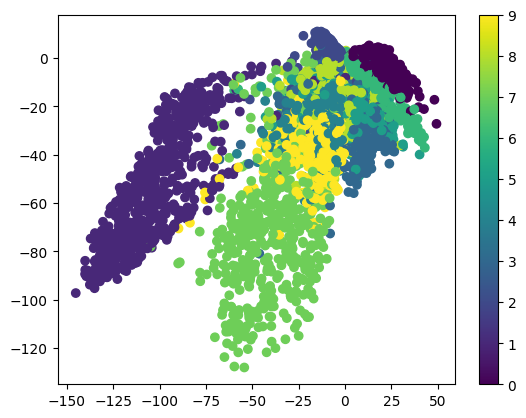

In [17]:
# Выведем использование скрытого пространства AE

h = encoderAE.predict(x_test[:6000], batch_size=batch_size)     # Предиктим энкодером первые 6000 цизображений ифр
plt.scatter(h[:, 0], h[:, 1] , c=y_test[:6000], cmap='viridis') # Выводим  скаттер координат точек скрытого пространства
plt.colorbar()                                                  # Выводим цветовую шкалу - каждому классу свой цвет
plt.show()                                                      # Отрисуем картинку

Повод огорчиться: точки в скрытом пространстве весьма сильно рассеяны. Чем это плохо? Допустим, нам нужно изображение цифры. Генерируем точки в пространстве `Z` и получаем:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━

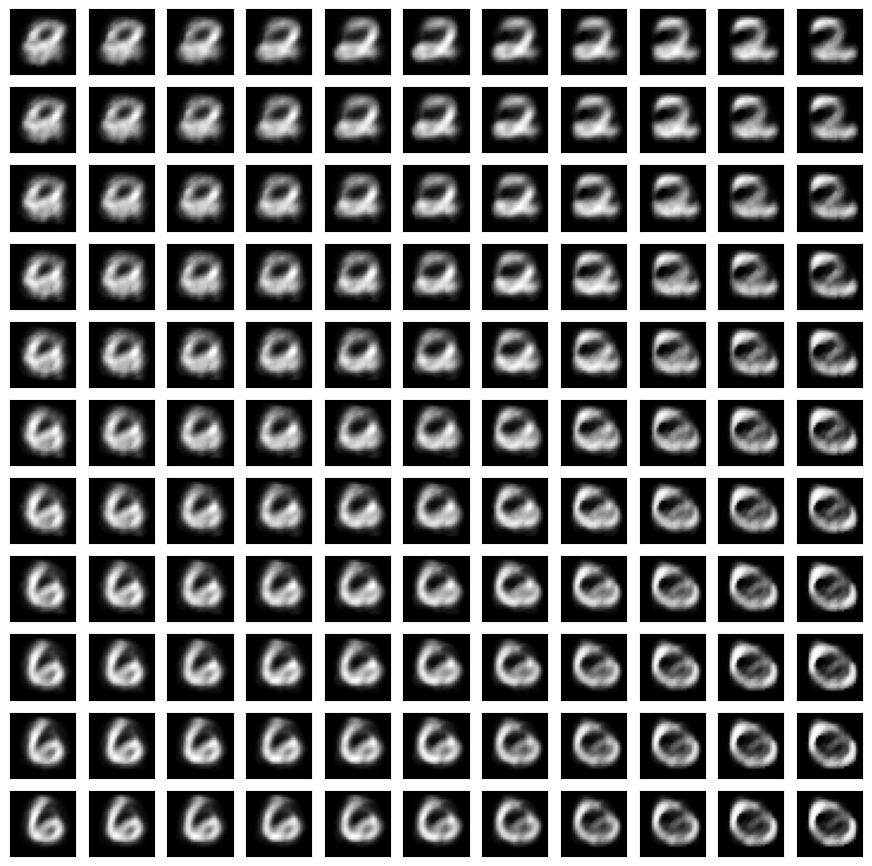

In [18]:
# Выведем 100 цифр, сгенерированных декодером

showResult(decoderAE)

Да, получаем много изображений чего-то усредненного по всем изображениям.
Из 100 попыток ни разу не попали. Мы не можем использовать такой декодер как генератор контента. Просто не попадем в точку, которую знает декодер.

Давайте сделаем АЕ поумнее.

### Сверточный AE

In [19]:
# Нормализация, приведем массивы пикселей к диапазону 0...1 для обучающей выборки
x_train = xs_train / 255.
x_test = xs_test / 255.

# Добавим 1 размерность numpy-массиву обучающей выборки
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test  = np.reshape(x_test,  (len(x_test),  28, 28, 1))

In [20]:
# Создадим сверточный энкодер

input_img = Input(shape=(28, 28, 1))                     # Добавим входной слой
x = encoderBlock(input_img, neu=32, kernel=3, strides=1) # Добавим 1-й блок свертка+нормализация+активашка
x = encoderBlock(x, neu=64, kernel=3, strides=2)         # Добавим 2-й блок свертка+нормализация+активашка
x = encoderBlock(x, neu=64, kernel=3, strides=2)         # Добавим 3-й блок свертка+нормализация+активашка
x = encoderBlock(x, neu=64, kernel=3, strides=1)         # Добавим 4-й блок свертка+нормализация+активашка
flatten =Flatten()(x)                                    # Добавим Flatten
encoded = Dense(2, activation='linear')(flatten)         # Добавим выходной dense слой

In [21]:
# Создадим сверточный декодер

input_enc = Input(shape=(2,))                            # Добавим входной слой
x = Dense(3136, name='dense_1')(input_enc)               # Добавим dense в 7х7х64 = 3136 нейронами
x = Reshape((7, 7, 64))(x)                               # Решейпим 1D тензор в 3D тензор
x= decoderBlock(x, neu=64, kernel=3, strides=1)          # Добавим 1-й блок обратная свертка+нормализация+активашка
x= decoderBlock(x, neu=64, kernel=3, strides=2)          # Добавим 2-й блок обратная свертка+нормализация+активашка
x= decoderBlock(x, neu=32, kernel=3, strides=2)          # Добавим 3-й блок обратная свертка+нормализация+активашка

decoded = Conv2DTranspose(1, 3, 1,padding='same', activation='sigmoid', name='conv_transpose_4')(x)# Добавим выходной слой

In [22]:
# Соберем наши нейронки

encoderAEC = keras.Model(input_img, encoded, name="encoder")                                # Соберем энкодер
decoderAEC = keras.Model(input_enc, decoded, name="decoder")                                # Соберем декодер
autoencoder = keras.Model(input_img, decoderAEC(encoderAEC(input_img)), name="autoencoder") # Соберем автокодировщик
autoencoder.compile(optimizer='adam', loss='mean_squared_error')                            # Скомпилируем автокодировкщик

In [23]:
# Выведем состав энкодера

encoderAEC.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │         6,274 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,842 (390.01 KB)

 Trainable params: 99,394 (388.26 KB)

 Non-trainable params: 448 (1.75 KB)

In [24]:
# Выведем состав декодера

decoderAEC.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 64)       │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_transpose_4                │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,657 (401.00 KB)

 Trainable params: 102,337 (399.75 KB)

 Non-trainable params: 320 (1.25 KB)

In [25]:
# Обучим сверточный автокодировщик

autoencoder.fit(x_train,       # Обучающая выборка
                x_train,       # "Labels" обучающей выборки
                epochs=10,     # 10 эпох
                batch_size=64, # размер батча
                shuffle=True)  # обучающую выборку перемешиваем

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 0.0585
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0466
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0448
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0438
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0432
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0427
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0423
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0418
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0416
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0412


И вновь смотрим на точки в **скрытом пространстве**:

100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


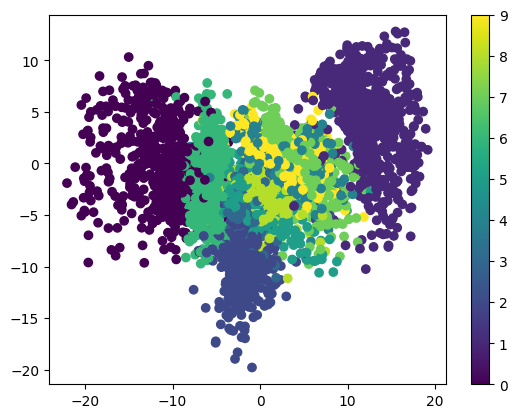

In [26]:
# Выведем использование скрытого пространства

h = encoderAEC.predict(x_test[:6000], batch_size=batch_size)     # Предиктим энкодером первые 6000 изображений ифр
plt.scatter(h[:, 0], h[:, 1] , c=y_test[:6000], cmap='viridis') # Выводим  скаттер координат точек скрытого пространства
plt.colorbar()                                                  # Выводим цветовую шкалу - каждому классу свой цвет
plt.show()                                                      # Отрисуем картинку

Уже лучше! Точки менее размазаны по плоскости, есть устойчивые области, где сгруппированы точки одного класса.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━

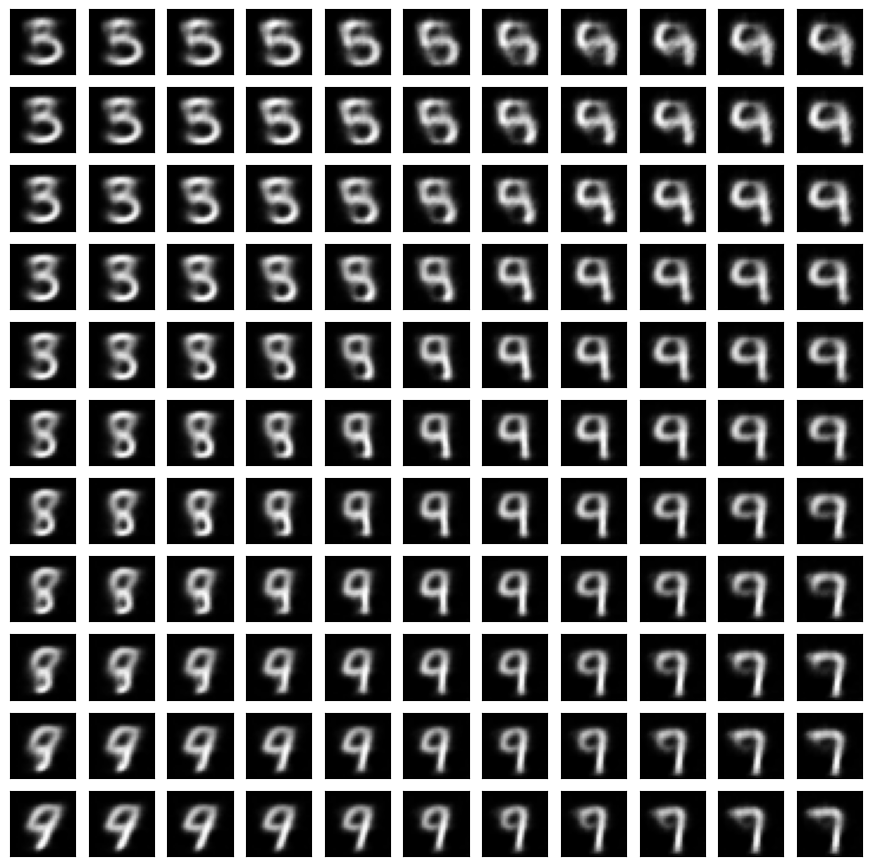

In [27]:
# Выведем 100 цифр, сгенерированных декодером

showResult(decoderAEC)

Пробежимся по окрестностям `0,0`. Ситуация более приятная. Цифры начинают различаться. Видно, как изображения одних цифр плавно перетекают в изображения других цифр. Причина тому – более плотная группировка точек.

Давайте продвинемся еще дальше и вместо точки в скрытом пространстве создадим облачко, а затем потребуем, чтобы AE склеил из них тучку.

## VAE

### Простой VAE
В сущности VAE – это тот же AE по структуре (энкодер и декодер). Но между ними сделали один слой, который размазывает точки в скрытом пространстве, от чего из точки получается пятно. Кроме того, мы ввели дополнительный лосс, который собирает все пятна вместе. Далее будет понятна реализация этих нововведений.

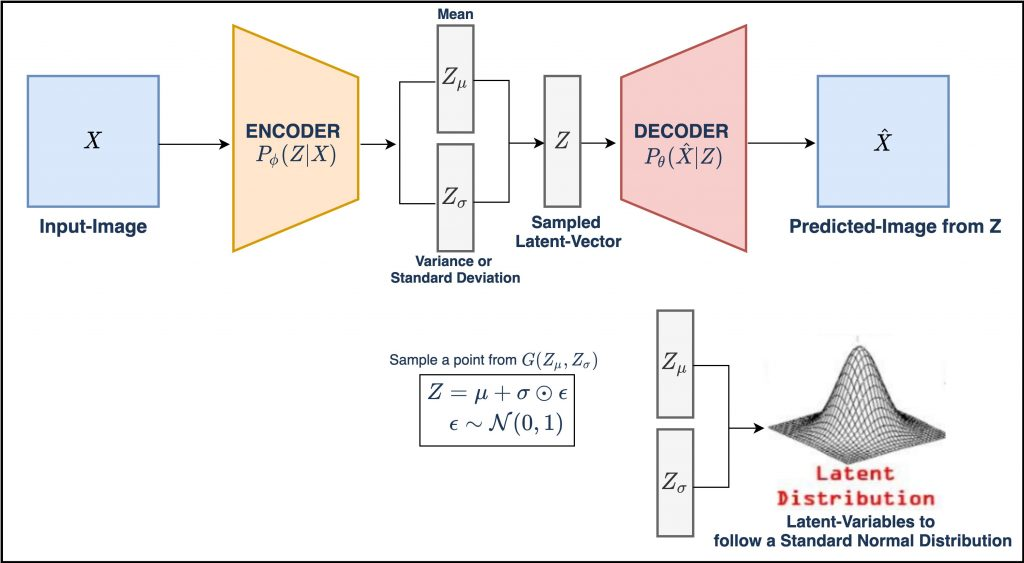

In [28]:
# Нормализация, приведем массивы пикселей к диапазону 0...1 для обучающей выборки
x_train = xs_train / 255.
x_test = xs_test / 255.

# Добавим 1 размерность numpy-массиву обучающей выборки
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test  = np.reshape(x_test,  (len(x_test),  28, 28, 1))

In [29]:
# Функция создания блока энкодера-декодера

def dropout_and_batch(xin): # xin - входной тензор

  x = BatchNormalization()(xin) # Добавим слой нормализации
  x = Dropout(0.3)(x)           # Добавим дроаут

  # Вернем выходной тензор
  return x

In [30]:
#  Создадим энкодер

input_img = Input((28, 28, 1))       # Добавим входной слой
x = Flatten()(input_img)             # Добавим Flatten
x = Dense(256, activation='relu')(x) # Добавим dense на 256 нейронов
x = dropout_and_batch(x)             # Добавим блок дропаут + нормализация
x = Dense(128, activation='relu')(x) # Добавим dense на 128 нейронов
x = dropout_and_batch(x)             # Добавим блок дропаут + нормализация

Выход энкодера подаем сразу, параллельно на два dense-слоя – формирователи мат. ожидания и логарифма дисперсии. Здесь вместо точки в пространстве `Z` формируется облачко:

In [31]:
z_mean = Dense(hidden_dim)(x)        # Добавим dense для мат.ожидания
z_log_var = Dense(hidden_dim)(x)     # Добавим dense для логарифма дисперсии

In [32]:
import keras.ops as ops
import keras.random as kr

def noiser(args):
    z_mean, z_log_var = args

    batch = ops.shape(z_mean)[0]  # размер батча берём из KerasTensor
    N = kr.normal(shape=(batch, hidden_dim), mean=0.0, stddev=1.0)

    return z_mean + ops.exp(0.5 * z_log_var) * N

h = keras.layers.Lambda(noiser, output_shape=(hidden_dim,))([z_mean, z_log_var])
      # Создадим свой слой - лямбда. На входе мат.ожидание и логарифм дисперсии
                                                                          # На выходе - тензор случайных чисел

In [33]:
# Соберем энкодер

encoderVAE = keras.Model(input_img, [z_mean, z_log_var, h], name='encoder')

In [34]:
#  Создадим декодер

input_dec = Input(shape=(hidden_dim,))      # Добавим входной слой
d = Dense(128, activation='relu')(input_dec)# Добавим 1й dense
d = dropout_and_batch(d)                    # Добавим 1й блок дропаут+нормализация
d = Dense(256, activation='relu')(d)        # Добавим 2й dense
d = dropout_and_batch(d)                    # Добавим 2й блок дропаут+нормализация
d = Dense(28*28, activation='sigmoid')(d)   # Добавим выходной dense
decoded = Reshape((28, 28, 1))(d)           # Решейпим до исходной размерности картинки


In [35]:
# Соберем декодер

decoderVAE = keras.Model(input_dec, decoded, name='decoder')

In [36]:
# Запишем выражение для декодера, заметим, что за вход декодера подается только 1 их выходов энкодера

outputs = decoderVAE(encoderVAE(input_img)[2])    # Заметим, что на только 1 из 3х выходов энкодера будем использовать

In [37]:
# Соберем наши сетки

vae = keras.Model(input_img, outputs, name="vae")

Функции потерь в `Keras` всегда принимают два параметра `y_true` и `y_pred`. Обратимся к справочнику по Keras. `BinaryCrossentropy`, `MeanSquaredErrory` и  другие - это все функции этих двух параметров, `y_true` и `y_pred`. Это истиннное и предсказанное  моделью значение Y.

Но некоторые, более сложные потери, не записать таким образом. Для нашего случая, функция потерь зависит от дополнительных тензоров, а именно `z_log_var` и `z_mean`, которые невозможно отдать функции потерь в качестве дополнительных аргументов.

Самый простой выход - это использование метода `model.add_loss()`. Он  не имеет такого ограничения и позволяет записывать гораздо более сложные функции потерь, которые зависят от многих других тензоров.

Запишем выражение расчета потерь нашего `VAE`. В нем учтем ошибку восстановления изображения автокодировщиком (`reconstruction_loss`  - функция потерь `MSE`)  и дивергенцию Кульбака - Лейблера - расхождение распределения точек в скрытом пространстве от нормального.

In [38]:
import keras
import keras.ops as ops

class VAELossLayer(keras.layers.Layer):
    def call(self, inputs):
        input_img, outputs, z_mean, z_log_var = inputs

        # MSE вручную (т.к. keras.losses.mse нет)
        reconstruction_loss = ops.mean(ops.square(input_img - outputs), axis=(1, 2, 3))
        reconstruction_loss *= 28 * 28

        kl_loss = 1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var)
        kl_loss = -0.5 * ops.sum(kl_loss, axis=-1)

        vae_loss = ops.mean(reconstruction_loss + kl_loss)
        self.add_loss(vae_loss)

        return outputs  # просто пробрасываем реконструкцию

# Использование:
outputs = VAELossLayer()([input_img, outputs, z_mean, z_log_var])
vae = keras.Model(input_img, outputs)                                    # Отдадим наш лосс VAE

In [39]:
# Выведем состав энкодера

encoderVAE.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 784)       │          0 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │    200,960 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_6[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_7[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 2)         │        258 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 2)         │        258 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 2)         │          0 │ dense_8[0][0],    │
│                     │                   │            │ dense_9[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 235,908 (921.52 KB)

 Trainable params: 235,140 (918.52 KB)

 Non-trainable params: 768 (3.00 KB)

In [40]:
# Выведем состав декодера

decoderVAE.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 784)            │       201,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,432 (923.56 KB)

 Trainable params: 235,664 (920.56 KB)

 Non-trainable params: 768 (3.00 KB)

In [41]:
 # Компилируем VAE

vae.compile(optimizer='adam')

In [42]:
# Запускаем обучениe

vae.fit(x_train,       # Обучающая выборка
        x_train,       # "Labels" обучающей выборки
        epochs=15,      # 15 эпох
        batch_size=60, # размер батча
        shuffle=True)  # обучающую выборку перемешиваем

Epoch 1/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 95.9764
Epoch 2/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 45.8662
Epoch 3/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 44.0320
Epoch 4/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 43.3397
Epoch 5/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 42.9908
Epoch 6/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 42.6209
Epoch 7/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 42.4040
Epoch 8/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 42.0423
Epoch 9/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 41.7611
Epoch 10/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 41.7074
Epoch 11/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 41.4119
Epoch 12/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 41.4653
Epoch 13/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 41.2941
Epoch 14/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 41.2042
Epoch 15/15
10

Смотрим на точки в **скрытом пространстве**:

100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


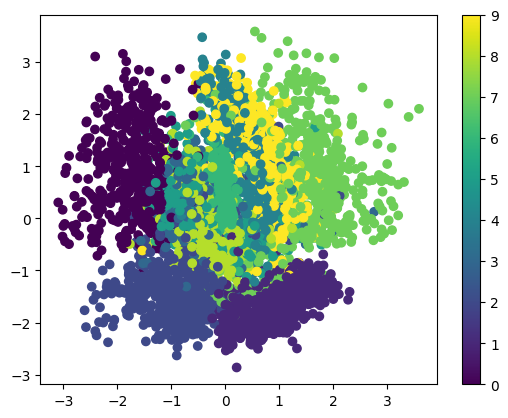

In [43]:
h = encoderVAE.predict(x_test[:6000], batch_size=batch_size)          # Предиктим энкодером первые 6000 цизображений ифр

plt.scatter(h[2][:, 0], h[2][:, 1] , c=y_test[:6000], cmap='viridis') # Выводим  скаттер координат точек скрытого пространства
plt.colorbar()                                                        # Выводим цветовую шкалу - каждому классу свой цвет
plt.show()                                                            # Отрисуем картинку

Скрытое пространство стало еще плотнее. Ждем улучшения результатов генерации изображений.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━

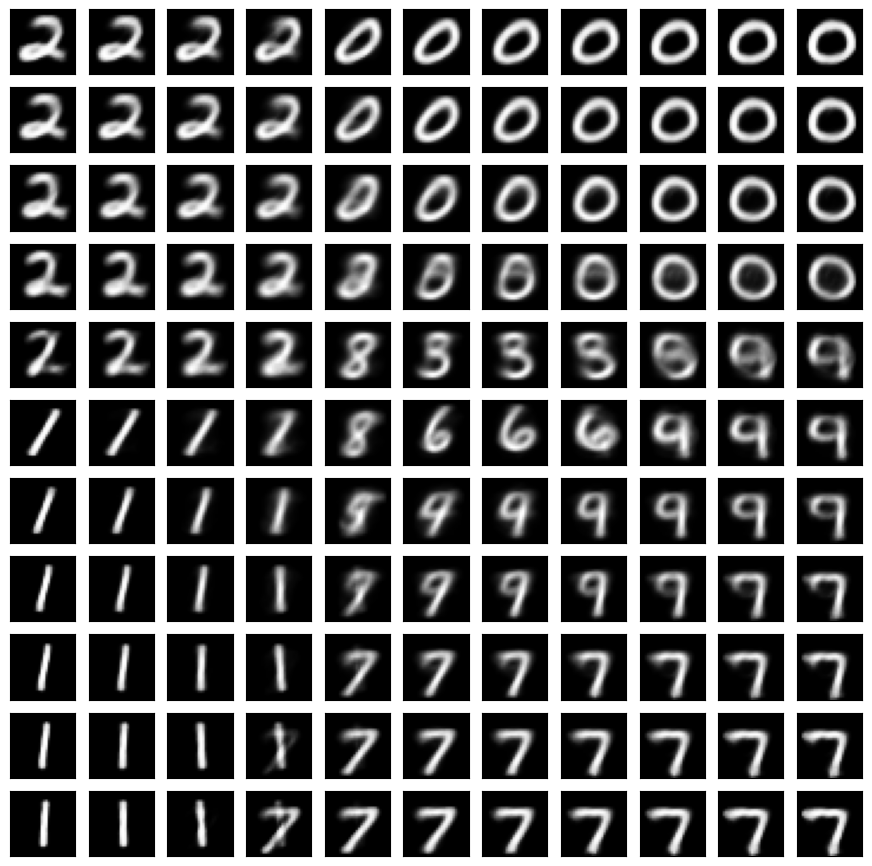

In [44]:
# Выведем 100 цифр, сгенерированных декодером

showResult(decoderVAE)

Получили несколько легко узнаваемых изображений цифр. Количество бракованных цифр уменьшается на глазах. Проверим, как себя поведет более умный VAE.

### Сверточный VAE


In [45]:
# Нормализация, приведем массивы пикселей к диапазону 0...1 для обучающей выборки
x_train = xs_train / 255.
x_test = xs_test / 255.

# Добавим 1 размерность numpy-массиву обучающей выборки
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test  = np.reshape(x_test,  (len(x_test),  28, 28, 1))

In [ ]:
# Создадим сверточный энкодер

input_img = Input(shape=(28, 28, 1))                     # Добавим входной слой
x = encoderBlock(input_img, neu=32, kernel=3, strides=1) # Добавим 1-й блок свертка+нормализация+активашка
x = encoderBlock(x, neu=64, kernel=3, strides=2)         # Добавим 2-й блок свертка+нормализация+активашка
x = encoderBlock(x, neu=64, kernel=3, strides=2)         # Добавим 3-й блок свертка+нормализация+активашка
x = encoderBlock(x, neu=64, kernel=3, strides=1)         # Добавим 4-й блок свертка+нормализация+активашка
flatten =Flatten()(x)                                    # Добавим Flatten
x = Dense(2, activation='linear')(flatten)               # Добавим выходной dense слой

In [46]:
z_mean = Dense(hidden_dim)(x)        # Добавим dense для получения мат.ожидания
z_log_var = Dense(hidden_dim)(x)     # Добавим dense для получения логарифма дисперсии

In [47]:
import keras.ops as ops
import keras.random as kr

def noiser(args):
    z_mean, z_log_var = args

    batch = ops.shape(z_mean)[0]  # размер батча берём из KerasTensor
    N = kr.normal(shape=(batch, hidden_dim), mean=0.0, stddev=1.0)

    return z_mean + ops.exp(0.5 * z_log_var) * N

h = keras.layers.Lambda(noiser, output_shape=(hidden_dim,))([z_mean, z_log_var])
      # Создадим свой слой - лямбда. На входе мат.ожидание и логарифм дисперсии
                                                                          # На выходе - тензор случайных чисел

In [48]:
 # Соберем энкодер

encoderVAEС = keras.Model(input_img, [z_mean, z_log_var, h], name='encoder')

In [49]:
# Создадим сверточный декодер

input_enc = Input(shape=(2,))                            # Добавим входной слой
x = Dense(3136, name='dense_1')(input_enc)               # Добавим dense в 7х7х64 = 3136 нейронами
x = Reshape((7, 7, 64))(x)                               # Решейпим 1D тензор в 3D тензор
x= decoderBlock(x, neu=64, kernel=3, strides=1)          # Добавим 1-й блок обратная свертка+нормализация+активашка
x= decoderBlock(x, neu=64, kernel=3, strides=2)          # Добавим 2-й блок обратная свертка+нормализация+активашка
x= decoderBlock(x, neu=32, kernel=3, strides=2)          # Добавим 3-й блок обратная свертка+нормализация+активашка

decoded = Conv2DTranspose(1, 3, 1,padding='same', activation='sigmoid', name='conv_transpose_4')(x)# Добавим выходной слой

In [50]:
# Соберем декодер

decoderVAEС = keras.Model(input_enc, decoded, name='decoder')

In [51]:
# Запишем выражение для декодера, заметим, что за вход декодера подается только 1 их выходов энкодера

outputs = decoderVAEС(encoderVAEС(input_img)[2])

In [52]:
# Соберем наши сетки

vaec = keras.Model(input_img, decoderVAEС(encoderVAEС(input_img)[2])) # Соберем VAE

In [53]:
import keras
import keras.ops as ops

class VAELossLayer(keras.layers.Layer):
    def call(self, inputs):
        input_img, outputs, z_mean, z_log_var = inputs

        # MSE вручную (т.к. keras.losses.mse нет)
        reconstruction_loss = ops.mean(ops.square(input_img - outputs), axis=(1, 2, 3))
        reconstruction_loss *= 28 * 28

        kl_loss = 1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var)
        kl_loss = -0.5 * ops.sum(kl_loss, axis=-1)

        vae_loss = ops.mean(reconstruction_loss + kl_loss)
        self.add_loss(vae_loss)

        return outputs  # просто пробрасываем реконструкцию

# Использование:
outputs = VAELossLayer()([input_img, outputs, z_mean, z_log_var])
vaec = keras.Model(input_img, outputs)                                   # Отдадим наш лосс VAE


In [54]:
# Выведем состав энкодера
encoderVAEС.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 784)       │          0 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │    200,960 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_6[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_7[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 2)         │        258 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 2)         │        258 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 2)         │          0 │ dense_13[0][0],   │
│                     │                   │            │ dense_14[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 235,908 (921.52 KB)

 Trainable params: 235,140 (918.52 KB)

 Non-trainable params: 768 (3.00 KB)

In [55]:
#  Выведем состав энкодера
decoderVAEС.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 7, 7, 64)       │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_transpose_4                │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,657 (401.00 KB)

 Trainable params: 102,337 (399.75 KB)

 Non-trainable params: 320 (1.25 KB)

In [56]:
# Компилируем VAE

vaec.compile(optimizer='adam') # оптимайзер ADAM

In [57]:
# Запускаем обучениe

vaec.fit(x_train,      # Обучающая выборка
        x_train,       # "Labels" обучающей выборки
        epochs=15,     # 15 эпох
        batch_size=60, # размер батча
        shuffle=True)  # обучающую выборку перемешиваем


Epoch 1/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - loss: 60.5807
Epoch 2/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 42.2891
Epoch 3/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 41.5452
Epoch 4/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 41.0126
Epoch 5/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 40.9034
Epoch 6/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 40.7300
Epoch 7/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 40.4843
Epoch 8/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 40.3925
Epoch 9/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 40.2271
Epoch 10/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 40.1429
Epoch 11/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 40.0735
Epoch 12/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 39.8364
Epoch 13/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 39.8614
Epoch 14/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 39.7972
Epoch 15/15
10

Смотрим на точки в **скрытом пространстве**:

100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


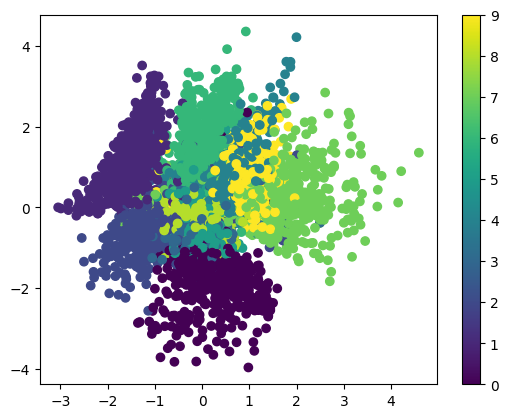

In [58]:
h = encoderVAEС.predict(x_test[:6000], batch_size=batch_size)    # Предиктим энкодером первые 6000 цизображений ифр
plt.scatter(h[2][:, 0], h[2][:, 1] , c=y_test[:6000], cmap='viridis') # Выводим  скаттер координат точек скрытого пространства
plt.colorbar()                                                  # Выводим цветовую шкалу - каждому классу свой цвет
plt.show()                                                      # Отрисуем картинку

Получили более компактное использование скрытого пространства.
Изображения цифр еще лучше.

Генерация цифр – это хорошо, но ведь есть много других задач для AE. И везде важно скрытое пространство, поскольку оно показывает качество работы нашего AE. Можно с уверенностью ожидать, что в задачах восстановления изображения, шумоподавления AE с непрерывной зоной использования скрытого пространства покажет лучшие результаты.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━

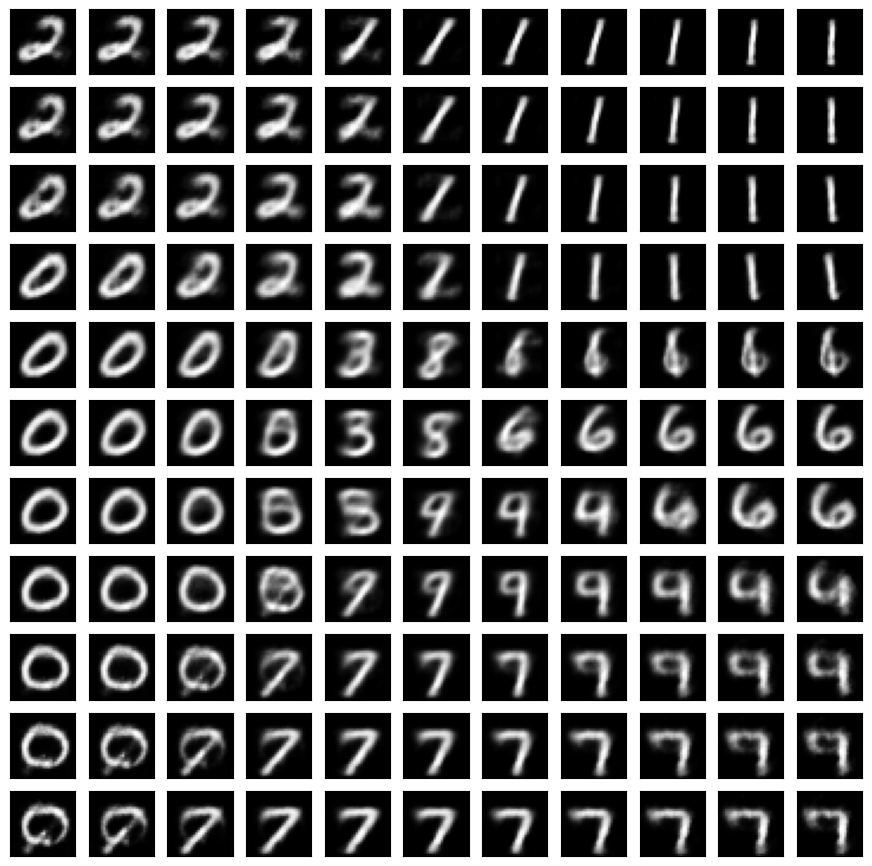

In [59]:
# Выведем 100 цифр, сгенерированных декодером

showResult(decoderVAEС)

## CVAE

### Простой CVAE

VAE с условием (CVAE) – это наш знакомый VAE, только на энкодер и декодер которых дополнительно подают метки классов объектов (изображений). Довольно сложно определить, куда и в каком виде подавать метки. Это зависит от формата данных в нашем датасете, типов энкодера и декодера. В одном случае метки класса будут поданы на вход, в другом – на промежуточные слои. В одном случае метки будут в виде OHE, в другом – 2D векторы. Вариантов весьма много.

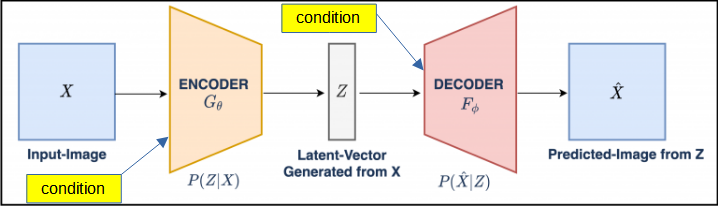

In [60]:
hidden_dim = 2
num_classes = 10
batch_size = 100  # должно быть кратно 60 000 и 10 0000

In [61]:
# Нормализация, приведем массивы пикселей к диапазону 0...1 для обучающей выборки
x_train = xs_train / 255.
x_test = xs_test / 255.

# Добавим 1 размерность numpy-массиву обучающей выборки
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test  = np.reshape(x_test,  (len(x_test),  28, 28, 1))

In [62]:
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

In [63]:
# Создадим простой энкодер

input_img = Input((28, 28, 1))       # Добавим входной слой
fl = Flatten()(input_img)             # Добавим Flatten
lb = Input(shape=(num_classes,))     # Добавим входной слой для метки класса
x = concatenate([fl, lb])            # конкатенируем метку класса изображение
x = Dense(256, activation='relu')(x) # Добавим dense на 256 нейронов
x = dropout_and_batch(x)             # Добавим блок дропаут + нормализация
x = Dense(128, activation='relu')(x) # Добавим dense на 128 нейронов
x = dropout_and_batch(x)             # Добавим блок дропаут + нормализация

In [64]:
z_mean = Dense(hidden_dim)(x)        # Добавим dense для получения мат.ожидания
z_log_var = Dense(hidden_dim)(x)     # Добавим dense для получения логарифма дисперсии

In [65]:
import keras.ops as ops
import keras.random as kr

def noiser(args):
    z_mean, z_log_var = args

    batch = ops.shape(z_mean)[0]  # размер батча берём из KerasTensor
    N = kr.normal(shape=(batch, hidden_dim), mean=0.0, stddev=1.0)

    return z_mean + ops.exp(0.5 * z_log_var) * N

h = keras.layers.Lambda(noiser, output_shape=(hidden_dim,))([z_mean, z_log_var])
      # Создадим свой слой - лямбда. На входе мат.ожидание и логарифм дисперсии
                                                                          # На выходе - тензор случайных чисел

In [66]:
# Соберем энкодер

encoderCVAE = keras.Model([input_img, lb], [z_mean, z_log_var, h], name='encoder')

In [67]:
#  Создадим декодер

input_dec = Input(shape=(hidden_dim,))      # Добавим входной слой
lb_dec = Input(shape=(num_classes,))        # Добавим вход для метки класса
d = concatenate([input_dec, lb_dec])        # Конкатенируем метку класса и вектор скрытого пространства
d = Dense(128, activation='relu')(d)        # Добавим 1й dense
d = dropout_and_batch(d)                    # Добавим 1й блок дропаут+нормализация
d = Dense(256, activation='relu')(d)        # Добавим 2й dense
d = dropout_and_batch(d)                    # Добавим 2й блок дропаут+нормализация
d = Dense(28*28, activation='sigmoid')(d)   # Добавим выходной dense
decoded = Reshape((28, 28, 1))(d)           # Решейпим до исходной размерности картинки

In [68]:
# Соберем декодер

decoderCVAE = keras.Model([input_dec, lb_dec], decoded, name='decoder')

In [79]:
# Запишем выражение для декодера, заметим, что за вход декодера подается только 1 их выходов энкодера

outputs = decoderCVAE([encoderCVAE([input_img, lb])[2], lb_dec])

In [80]:
#Соберем наши CVAE
cvae = keras.Model([input_img, lb, lb_dec], outputs , name="cvae") # Соберем VAE

# Соберем вспомогательную модель
z_meaner = keras.Model([input_img, lb], z_mean)

# Соберем модель для переноса стиля
tr_style = keras.Model([input_img, lb, lb_dec], decoderCVAE([z_meaner([input_img, lb]), lb_dec]), name='tr_style')

In [86]:
import keras
import keras.ops as ops

class VAELossLayer(keras.layers.Layer):
    def call(self, inputs):
        input_img, outputs, z_mean, z_log_var = inputs

        # MSE вручную (т.к. keras.losses.mse нет)
        reconstruction_loss = ops.mean(ops.square(input_img - outputs), axis=(1, 2, 3))
        reconstruction_loss *= 28 * 28

        kl_loss = 1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var)
        kl_loss = -0.5 * ops.sum(kl_loss, axis=-1)

        vae_loss = ops.mean(reconstruction_loss + kl_loss)
        self.add_loss(vae_loss)

        return outputs  # просто пробрасываем реконструкцию

# Использование:
outputs = VAELossLayer()([input_img, outputs, z_mean, z_log_var])
cvae = keras.Model([input_img, lb, lb_dec], outputs)                                     # Отдадим наш лосс VAE

In [87]:
# Проверим состав энкодера

encoderCVAE.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 784)       │          0 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_8       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 794)       │          0 │ flatten_3[0][0],  │
│ (Concatenate)       │                   │            │ input_layer_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 256)       │    203,520 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_15[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 128)       │     32,896 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_16[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 2)         │        258 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 2)         │        258 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 2)         │          0 │ dense_17[0][0],   │
│                     │                   │            │ dense_18[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 238,468 (931.52 KB)

 Trainable params: 237,700 (928.52 KB)

 Non-trainable params: 768 (3.00 KB)

In [88]:
# Проверим состав декодера

decoderCVAE.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_10      │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 12)        │          0 │ input_layer_9[0]… │
│ (Concatenate)       │                   │            │ input_layer_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 128)       │      1,664 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_19[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 256)       │     33,024 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_20[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 784)       │    201,488 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_4 (Reshape) │ (None, 28, 28, 1) │          0 │ dense_21[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 237,712 (928.56 KB)

 Trainable params: 236,944 (925.56 KB)

 Non-trainable params: 768 (3.00 KB)

In [89]:
# Компилируем VAE

cvae.compile(optimizer='adam') # оптимайзер ADAM

In [90]:
# Обучим модель

cvae.fit([x_train, y_train_cat, y_train_cat],  # Обучающая выборка + метки классов для энкодера и декодера
         x_train,                              # Обучающая выборка
         epochs=15,                            # Число эпох
         batch_size=batch_size,                # Размер батча
         shuffle=True)                         # Обучающую выборку перемешиваем

Epoch 1/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 336.9585
Epoch 2/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 126.3452
Epoch 3/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 117.2960
Epoch 4/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 111.8192
Epoch 5/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 109.3761
Epoch 6/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 107.2655
Epoch 7/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 106.4475
Epoch 8/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 105.8107
Epoch 9/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 104.9486
Epoch 10/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 104.1982
Epoch 11/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 103.9550
Epoch 12/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 103.1084
Epoch 13/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 102.2699
Epoch 14/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 102.3570
Epoch 15/15
600/600 ━━━━━━━━

Смотрим на точки в **скрытом пространстве**:

60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


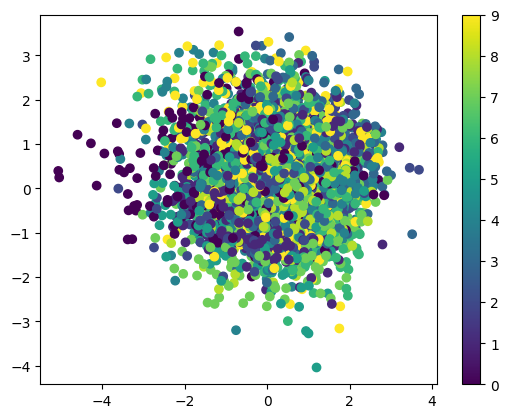

In [91]:
lb = lb_dec = y_test_cat                                                   # Копия меток классов
h = encoderCVAE.predict([x_test[:6000], lb[:6000]], batch_size=batch_size) # Предиктим точки скрытого пространства с учетом меток

plt.scatter(h[2][:, 0], h[2][:, 1] , c=y_test[:6000], cmap='viridis')        # Выводим  скаттер координат точек скрытого пространства
plt.colorbar()                                                               # Выводим цветовую шкалу - каждому классу свой цвет
plt.show()                                                                   # Отрисуем картинку

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━

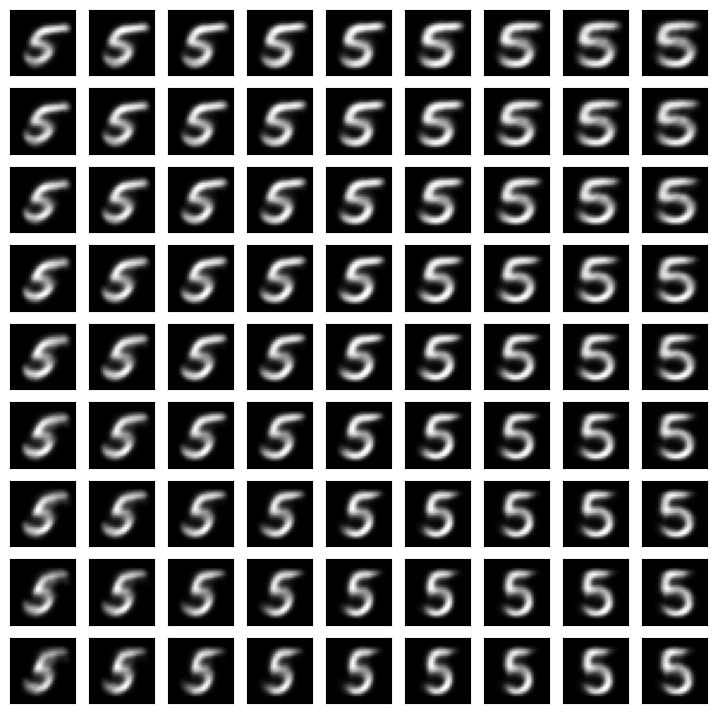

In [92]:
# Генерим разные пятерки

n = 4                                      # Просто нужная переменная
total = 2*n+1                              # Считаем общий размер картинки
input_lbl = np.zeros((1, num_classes))     # Заготовим массов из нулей, размерности = числу классов
input_lbl[0, 5] = 1                        # В пятый элемент запишем 1
plt.figure(figsize=(total, total))         # Заготовим общую картинку
h = np.zeros((1, hidden_dim))              # Заготовим массов из нулей, размерности = скрытого пространства
num = 1                                    # Создаем счетчик картинок

for i in range(-n, n+1):                   # Цикл по горизонтали
  for j in range(-n, n+1):                 # Цикл по вертикали
    ax = plt.subplot(total, total, num)    # Заготовим отдельную картинку для цифры
    num += 1                               # Инкрементируем счетчик картинок
    h[0, :] = [1*i/n, 1*j/n]               # Создадим точку из скрытого пространство
    img = decoderCVAE.predict([h, input_lbl])  # Предиктим цифру 5,  соответсвующую точке скрытого пространства
    plt.imshow(img.squeeze(), cmap='gray') # Отрисуем полученную цифру
    ax.get_xaxis().set_visible(False)      # Уберем ось X
    ax.get_yaxis().set_visible(False)      # Уберем ось Y

In [93]:
# Создадим функцию для отрисовки линейки картинок

def plot_digits(*images): # Список картинок

    images = [x.squeeze() for x in images]               # Понизим размерности картинок
    n = min([x.shape[0] for x in images])                # Найдем число картинок
    plt.figure(figsize=(n, len(images)))                 # Заготовим общее изображение
    for j in range(n):                                   # Цикл по
        for i in range(len(images)):                     # Цикл по списку картинок
            ax = plt.subplot(len(images), n, i*n + j + 1)# Заготовим картинку
            plt.imshow(images[i][j])                     # Отрисуем ее
            plt.gray()                                   # Рисуем в градациях серого
            ax.get_xaxis().set_visible(False)            # Уберем ось X
            ax.get_yaxis().set_visible(False)            # Уберем ось Y

    plt.show()                                           # Отрисуем итоговую картиную

Выполним перенос стиля. Источник стиля – десять экземпляров одной цифры.

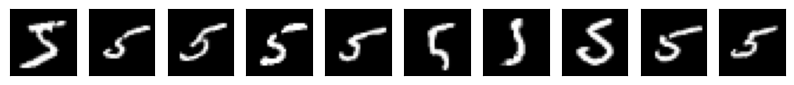

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 684ms/step


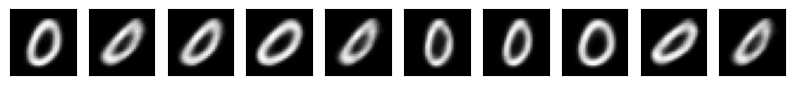

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


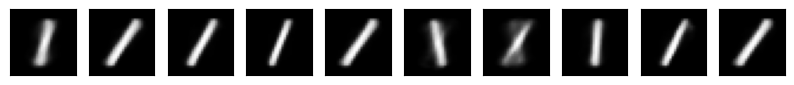

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


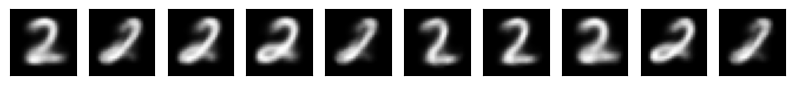

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


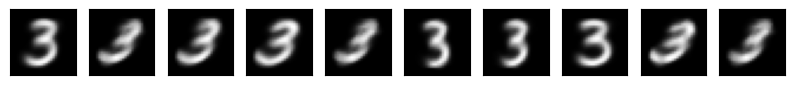

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


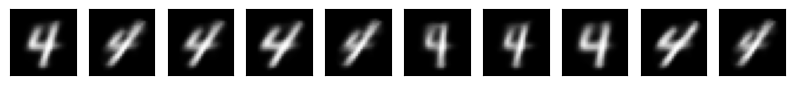

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


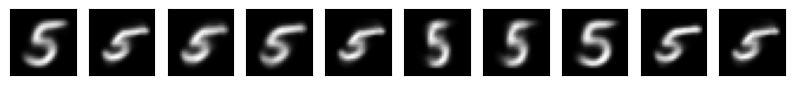

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


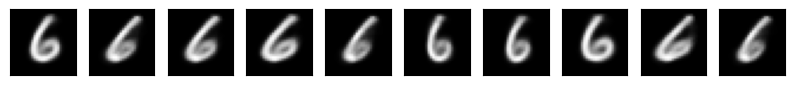

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


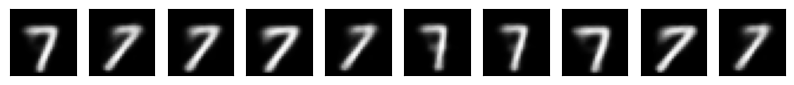

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


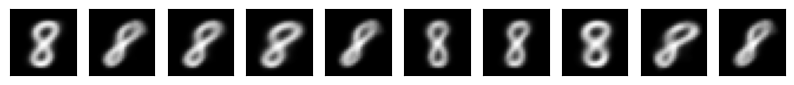

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


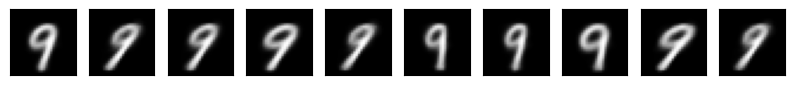

In [94]:
# Выберем цифры - источник
dig1 = 5

# Выберем число образцов
num = 10

# Отберем образцы стилей
X = x_train[y_train == dig1][:num]

# Создадим массив из нулей
lb_1 = np.zeros((num, num_classes))

# Заполним 5-ю колонку единицами
lb_1[:, dig1] = 1

# Отрисуем образцы стилей
plot_digits(X)

# Цикл по всем возможным классам цифр
for i in range(num_classes):

  lb_2 = np.zeros((num, num_classes)) # Создадим массив из нулей
  lb_2[:, i] = 1                      # Заполним i-ю колонку единицами

  Y = tr_style.predict([X, lb_1, lb_2], batch_size=num) # Выполним предикт
  plot_digits(Y)                                        # Отрисуем полученные цифры

###Сверточный CVAE

In [95]:
hidden_dim = 2
num_classes = 10
batch_size = 100  # должно быть кратно 60 000 и 10 0000

In [96]:
# Нормализация, приведем массивы пикселей к диапазону 0...1 для обучающей выборки
x_train = xs_train / 255.
x_test = xs_test / 255.

# Добавим 1 размерность numpy-массиву обучающей выборки
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test  = np.reshape(x_test,  (len(x_test),  28, 28, 1))

In [97]:
y_train_cat = keras.utils.to_categorical(y_train, num_classes)   # Метки обучающей выборка перегоним в one-hot encoding
y_test_cat = keras.utils.to_categorical(y_test, num_classes)     # Метки тестовой выборка перегоним в one-hot encoding

In [98]:
# Создадим сверточный энкодер

input_img = Input(shape=(28, 28, 1))                     # Добавим входной слой
x = encoderBlock(input_img, neu=32, kernel=3, strides=1) # Добавим 1-й блок свертка+нормализация+активашка
x = encoderBlock(x, neu=64, kernel=3, strides=2)         # Добавим 2-й блок свертка+нормализация+активашка
x = encoderBlock(x, neu=64, kernel=3, strides=2)         # Добавим 3-й блок свертка+нормализация+активашка
x = encoderBlock(x, neu=64, kernel=3, strides=1)         # Добавим 4-й блок свертка+нормализация+активашка
flatten =Flatten()(x)                                    # Добавим Flatten
lb = Input(shape=(num_classes,))                         # Добавим вход для метки класса
x = concatenate([flatten, lb])                           # Конкатенируем метку класса с выходом flatten
x = Dense(2, activation='linear')(x)               # Добавим выходной dense слой

In [99]:
z_mean = Dense(hidden_dim)(x)       # Добавим dense для получения мат.ожидания
z_log_var = Dense(hidden_dim)(x)    # Добавим dense для получения логарифма дисперсии

In [100]:
import keras.ops as ops
import keras.random as kr

def noiser(args):
    z_mean, z_log_var = args

    batch = ops.shape(z_mean)[0]  # размер батча берём из KerasTensor
    N = kr.normal(shape=(batch, hidden_dim), mean=0.0, stddev=1.0)

    return z_mean + ops.exp(0.5 * z_log_var) * N

h = keras.layers.Lambda(noiser, output_shape=(hidden_dim,))([z_mean, z_log_var])
      # Создадим свой слой - лямбда. На входе мат.ожидание и логарифм дисперсии
                                                                          # На выходе - тензор случайных чисел

In [101]:
 # Соберем энкодер

encoderCVAEC = keras.Model([input_img, lb], [z_mean, z_log_var, h], name='encoder')

In [102]:
# Создадим сверточный декодер

input_enc = Input(shape=(2,))                            # Добавим входной слой
lb_dec = Input(shape=(num_classes,))                     # Добавим вход для метки класса
d = concatenate([input_dec, lb_dec])                     # Конкатенируем метку класса и вектор скрытого пространства
x = Dense(3136, name='dense_1')(d)                       # Добавим dense в 7х7х64 = 3136 нейронами
x = Reshape((7, 7, 64))(x)                               # Решейпим 1D тензор в 3D тензор
x= decoderBlock(x, neu=64, kernel=3, strides=1)          # Добавим 1-й блок обратная свертка+нормализация+активашка
x= decoderBlock(x, neu=64, kernel=3, strides=2)          # Добавим 2-й блок обратная свертка+нормализация+активашка
x= decoderBlock(x, neu=32, kernel=3, strides=2)          # Добавим 3-й блок обратная свертка+нормализация+активашка

decoded = Conv2DTranspose(1, 3, 1,padding='same', activation='sigmoid', name='conv_transpose_4')(x)# Добавим выходной слой

In [103]:
# Соберем декодер

decoderCVAEC = keras.Model([input_dec, lb_dec], decoded, name='decoder')

In [104]:
# Запишем выражение для декодера, заметим, что за вход декодера подается только 1 их выходов энкодера

outputs = decoderCVAEC([encoderCVAEC([input_img, lb])[2], lb_dec])

In [105]:
#Соберем наши сетки
cvaec = keras.Model([input_img, lb, lb_dec], outputs, name="cvae") # Соберем VAE

# Соберем вспомогательную модель
z_meaner = keras.Model([input_img, lb], z_mean)

# Соберем модель для переноса стиля
tr_style = keras.Model([input_img, lb, lb_dec], decoderCVAEC([z_meaner([input_img, lb]), lb_dec]), name='tr_style')

In [113]:
import keras
import keras.ops as ops

class VAELossLayer(keras.layers.Layer):
    def call(self, inputs):
        input_img, outputs, z_mean, z_log_var = inputs

        # MSE вручную (т.к. keras.losses.mse нет)
        reconstruction_loss = ops.mean(ops.square(input_img - outputs), axis=(1, 2, 3))
        reconstruction_loss *= 28 * 28

        kl_loss = 1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var)
        kl_loss = -0.5 * ops.sum(kl_loss, axis=-1)

        vae_loss = ops.mean(reconstruction_loss + kl_loss)
        self.add_loss(vae_loss)

        return outputs  # просто пробрасываем реконструкцию

# Использование:
outputs = VAELossLayer()([input_img, outputs, z_mean, z_log_var])
cvaec = keras.Model([input_img, lb, lb_dec], outputs)                                      # Отдадим наш лосс VAE

In [114]:
# Компилируем СVAE

cvaec.compile(optimizer='adam') # оптимайзер ADAM

In [115]:
# Обучим модель

cvaec.fit([x_train, y_train_cat, y_train_cat], # Обучающая выборка + метки классов для энкодера и декодера
         x_train,                              # Обучающая выборка
         epochs=15,                            # Число эпох
         batch_size=batch_size,                # Размер батча
         shuffle=True)                         # Обучающую выборку перемешиваем


Epoch 1/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - loss: 182.7470
Epoch 2/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 136.9277
Epoch 3/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 131.5559
Epoch 4/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 129.2184
Epoch 5/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 127.7076
Epoch 6/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 126.5728
Epoch 7/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 125.7960
Epoch 8/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 124.5814
Epoch 9/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 124.0674
Epoch 10/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 123.4634
Epoch 11/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 123.3483
Epoch 12/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 123.4637
Epoch 13/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 122.9634
Epoch 14/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 122.9359
Epoch 15/15
60

Смотрим на точки в **скрытом пространстве**:

60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


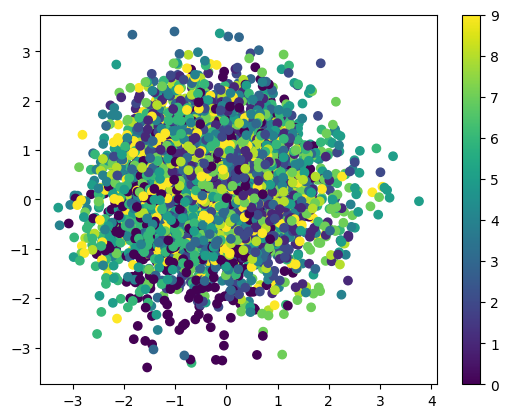

In [116]:
lb = lb_dec = y_test_cat                                                    # Копия меток классов
h = encoderCVAEC.predict([x_test[:6000], lb[:6000]], batch_size=batch_size) # Предиктим точки скрытого пространства с учетом меток

plt.scatter(h[2][:, 0], h[2][:, 1] , c=y_test[:6000], cmap='viridis')  # Выводим  скаттер координат точек скрытого пространства
plt.colorbar()                                                         # Выводим цветовую шкалу - каждому классу свой цвет
plt.show()                                                             # Отрисуем картинку

А вот – скрытое пространство CVAE. Можно огорчиться: в нем перепутаны все классы. Но, во-первых, мы не требовали от автокодировщика группировки точек по классам. Во-вторых, это и не нужно. Мы указываем декодеру метку класса – того, что мы от него ждем.

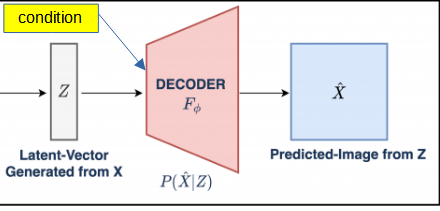

Берем метку класса, генерируем случайные векторы и подаем на декодер. Получаем изображения нужной цифры в разных стилях.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 615ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━

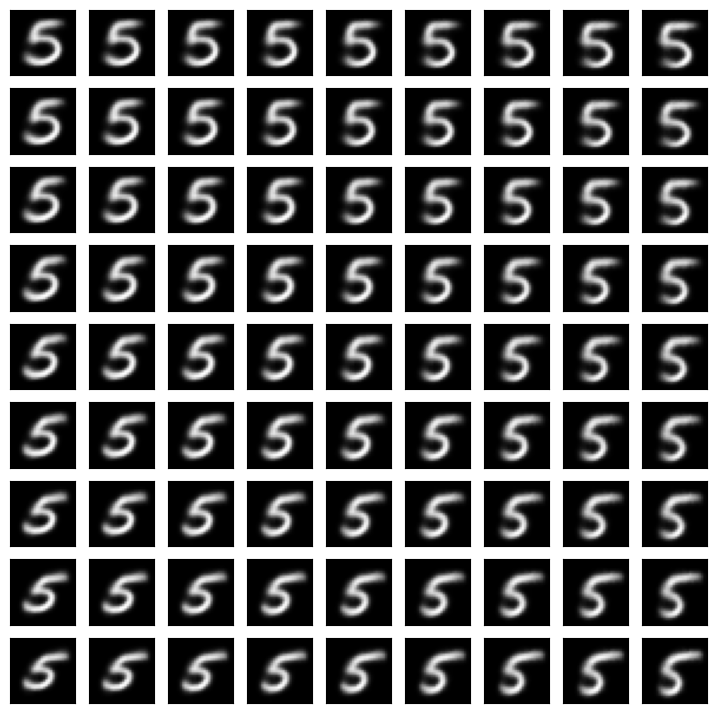

In [117]:
# Генерим разные пятерки

n = 4                                      # Просто нужная переменная
total = 2*n+1                              # Считаем общий размер картинки
input_lbl = np.zeros((1, num_classes))     # Заготовим массов из нулей, размерности = числу классов
input_lbl[0, 5] = 1                        # В пятый элемент запишем 1
plt.figure(figsize=(total, total))         # Заготовим общую картинку
h = np.zeros((1, hidden_dim))              # Заготовим массов из нулей, размерности = скрытого пространства
num = 1                                    # Создаем счетчик картинок

for i in range(-n, n+1):                   # Цикл по горизонтали
  for j in range(-n, n+1):                 # Цикл по вертикали
    ax = plt.subplot(total, total, num)    # Заготовим отдельную картинку для цифры
    num += 1                               # Инкрементируем счетчик картинок
    h[0, :] = [1*i/n, 1*j/n]               # Создадим точку из скрытого пространство
    img = decoderCVAEC.predict([h, input_lbl])  # Предиктим цифру 5,  соответсвующую точке скрытого пространства
    plt.imshow(img.squeeze(), cmap='gray') # Отрисуем полученную цифру
    ax.get_xaxis().set_visible(False)      # Уберем ось X
    ax.get_yaxis().set_visible(False)      # Уберем ось Y

Посмотрим на перенос стиля. Используя набор изображений цифры 5 как источник стиля, получим от декодера изображения цифр 0,1... 9 в разных стилях:

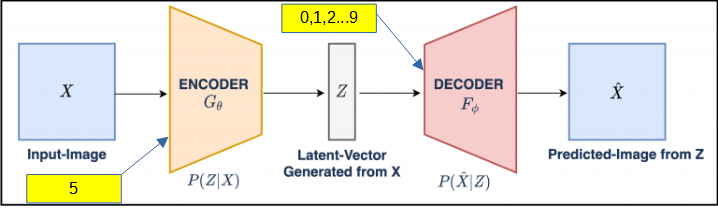

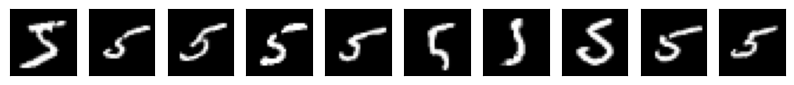

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


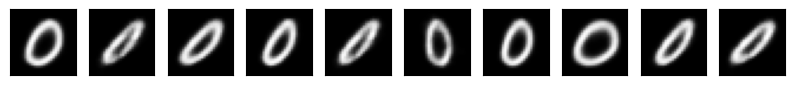

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


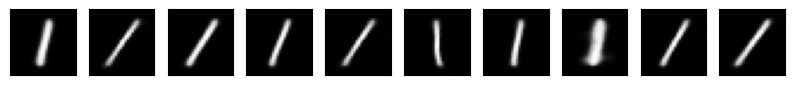

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


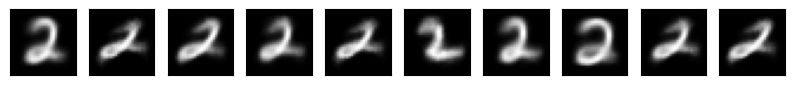

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


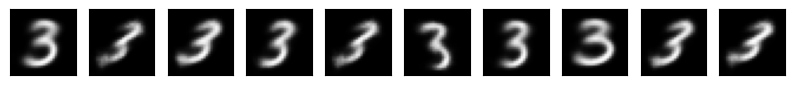

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


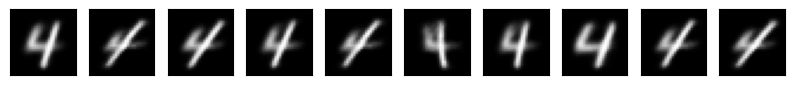

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


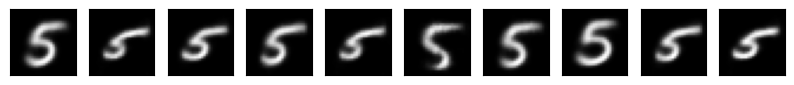

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


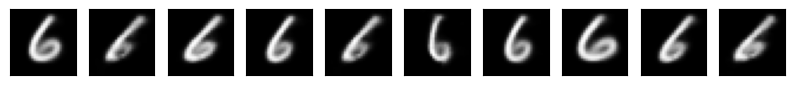

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


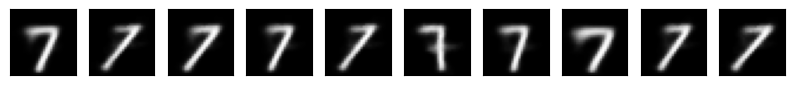

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


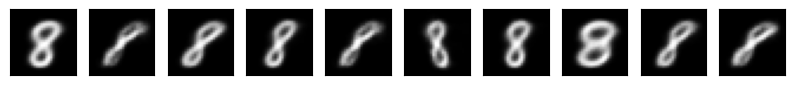

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


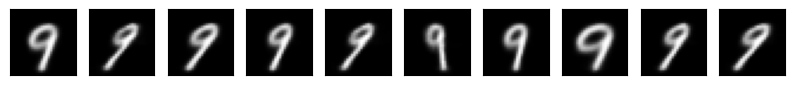

In [118]:
# Выберем цифры - источник
dig1 = 5

# Выберем число образцов
num = 10

# Отберем образцы стилей
X = x_train[y_train == dig1][:num]

# Создадим массив из нулей
lb_1 = np.zeros((num, num_classes))

# Заполним 5-ю колонку единицами
lb_1[:, dig1] = 1

# Отрисуем образцы стилей
plot_digits(X)

# Цикл по всем возможным классам цифр
for i in range(num_classes):

  lb_2 = np.zeros((num, num_classes)) # Создадим массив из нулей
  lb_2[:, i] = 1                      # Заполним i-ю колонку единицами

  Y = tr_style.predict([X, lb_1, lb_2], batch_size=num) # Выполним предикт
  plot_digits(Y)                                        # Отрисуем полученные цифру

## Напишем VAE с применением ООП

Нам необходимо оформить VAE как самостоятельный класс.
Такой шаг весьма полезен, если нужно перенести VAE из одного приложения в другое. Поместим в класс все необходимые переменные и методы. А затем просто создадим экземпляр этого класса.

AE готов к обучению и работе!

In [119]:
from tensorflow.keras import layers

# Созданим класс для генерации случайных чисел Sampling

class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""

    def call(self, inputs):               # На входе мат ожидание и дисперсия
        z_mean, z_log_var = inputs        # Разделим вход на 2 параметра
        batch = tf.shape(z_mean)[0]       # Найдем размер батча
        dim = tf.shape(z_mean)[1]         # Найдем размер элемента

        # Создадим тензор из нормальных случайных чисел параметрами (0,1)
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))

        #Создадим и вернем тензор в нужныммат.ожиданием и дисперсией
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [120]:
# Создадим энкодер

latent_dim = 2 #

encoder_inputs = keras.Input(shape=(28, 28, 1))                                       # Добавим входной слой
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)# Добавим сверточный слой
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)             # Добавим сверточный слой
x = layers.Flatten()(x)                                                               # Добавим Flatten
x = layers.Dense(16, activation="relu")(x)                                            # Добавим dense
z_mean = layers.Dense(latent_dim, name="z_mean")(x)                                   # Добавим dense для формирования мат.ожидания
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)                             # Добавим dense для формирования логарифма дисперсии
z = Sampling()([z_mean, z_log_var])                                                   # Добавим слой генерации случайных чисел
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")         # Соберем модель энкодера
encoder.summary()                                                                     # Выведем состав энкодера

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 14, 14,    │        320 │ input_layer_15[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 3136)      │          0 │ conv2d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 16)        │     50,192 │ flatten_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ dense_25[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense_25[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

 Non-trainable params: 0 (0.00 B)

In [121]:
# Создадим энкодер

latent_inputs = keras.Input(shape=(latent_dim,))                                        # Добавим входной слой
x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)                          # Добавим dense
x = layers.Reshape((7, 7, 64))(x)                                                       # Выполним решейп до размерности 7х7х64
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)      # Добавим обратную свертку
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)      # Добавим обратную свертку
decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x) # Добавим обратную свертку
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")                   # Соберем декодер
decoder.summary()                                                                       # Выведем состав декодера

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_6 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_9              │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_10             │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_11             │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

In [122]:
# Создадим класс вариационного автокодировщика

class VAE(keras.Model):

    # конcтруктор класса
    def __init__(self, encoder, decoder, **kwargs): # Подаем скомпилирование энкодер и декодер
        super(VAE, self).__init__(**kwargs)         # Инициализируем класс - предок
        self.encoder = encoder                      # Заполняем поле encoder
        self.decoder = decoder                      # Заполняем поле encoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss") #Указываем лоссы для total_loss_tracker
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )                                            #Указываем лоссы для reconstruction_loss_tracker
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss") #Указываем лоссы для вычисления дивергенции  Кульбака-Лейблера

    # Определяем метод metrics
    @property
    def metrics(self):

        # Вернем список лоссов
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    # Создадим метод train_step
    def train_step(self, data):

        # Создаем ленту градиентов
        with tf.GradientTape() as tape:

            # Получим выход энкодера - точка в скрытом слое
            z_mean, z_log_var, z = self.encoder(data)

            # Получим восстановленное изображение
            reconstruction = self.decoder(z)

            # Вычислим ошибку восстановления изображения
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2)
                )
            )
            # Вычислим ошибку Кульбака - Лейблера
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))

            # Вычислим суммарную ошибку на шаге
            total_loss = reconstruction_loss + kl_loss

        # Рассчитаем градиенты
        grads = tape.gradient(total_loss, self.trainable_weights)

        # Корректируем веса модели
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        # Пересчитаем общий лосс
        self.total_loss_tracker.update_state(total_loss)

        # Пересчитаем лосс восстановления изображеня
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)

        # Пересчитаем лосс Кульбака-Лейблера
        self.kl_loss_tracker.update_state(kl_loss)

        # Вернем словарь значений лоссов
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

In [123]:
# Объединяем обучающую и тестовую выборки - просто обучимся на всем датасете
mnist_digits = np.concatenate([xs_train, xs_test], axis=0) # Объединяем обучающую и тестовую выборки

# Добавляем размерность к массиву цифр, приводим к диапазону [0...1]
mnist_digits = np.expand_dims(mnist_digits, -1).astype("float32") / 255

# Создаем экземпляр класса автокодировщика
vae = VAE(encoder,  # Собранный энкодер
          decoder)  # Собранный декодер

# Компилируем модель
vae.compile(optimizer=keras.optimizers.Adam())

# Обучаем автокодировщик
vae.fit(mnist_digits,   # Обучающая выборка
        epochs=15,      # Число эпох
        batch_size=128) # Размер батча

Epoch 1/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - kl_loss: 1.6203 - loss: 257.8417 - reconstruction_loss: 256.2214
Epoch 2/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - kl_loss: 3.1882 - loss: 193.2545 - reconstruction_loss: 190.0663
Epoch 3/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 5.0312 - loss: 175.5908 - reconstruction_loss: 170.5596
Epoch 4/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - kl_loss: 5.6988 - loss: 166.6794 - reconstruction_loss: 160.9806
Epoch 5/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 5.9513 - loss: 162.9632 - reconstruction_loss: 157.0119
Epoch 6/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - kl_loss: 6.0608 - loss: 161.3411 - reconstruction_loss: 155.2803
Epoch 7/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - kl_loss: 6.1053 - loss: 159.8192 - reconstruction_loss: 153.7139
Epoch 8/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 6.1520 - loss: 159.0016 - reconstruction_loss: 152.8497
Epoch 9/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms

Смотрим на точки в **скрытом пространстве**:

60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


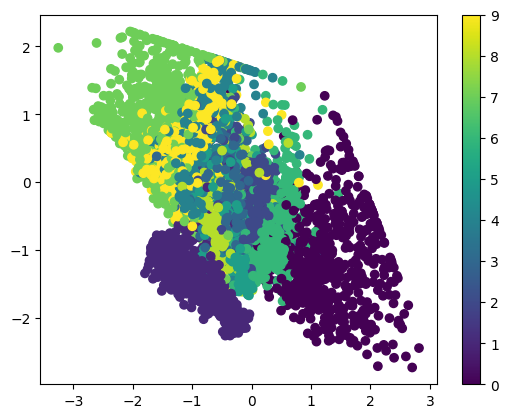

In [124]:
# Выведем скрытое пространство VAE

h,_,_ = vae.encoder.predict(x_train[:6000], batch_size=batch_size)  # Предиктим энкодером первые 6000 цизображений ифр
plt.scatter(h[:, 0], h[:, 1] , c=y_train[:6000], cmap='viridis')    # Выводим  скаттер координат точек скрытого пространства
plt.colorbar()                                                      # Выводим цветовую шкалу - каждому классу свой цвет
plt.show()                                                          # Отрисуем картинку

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━

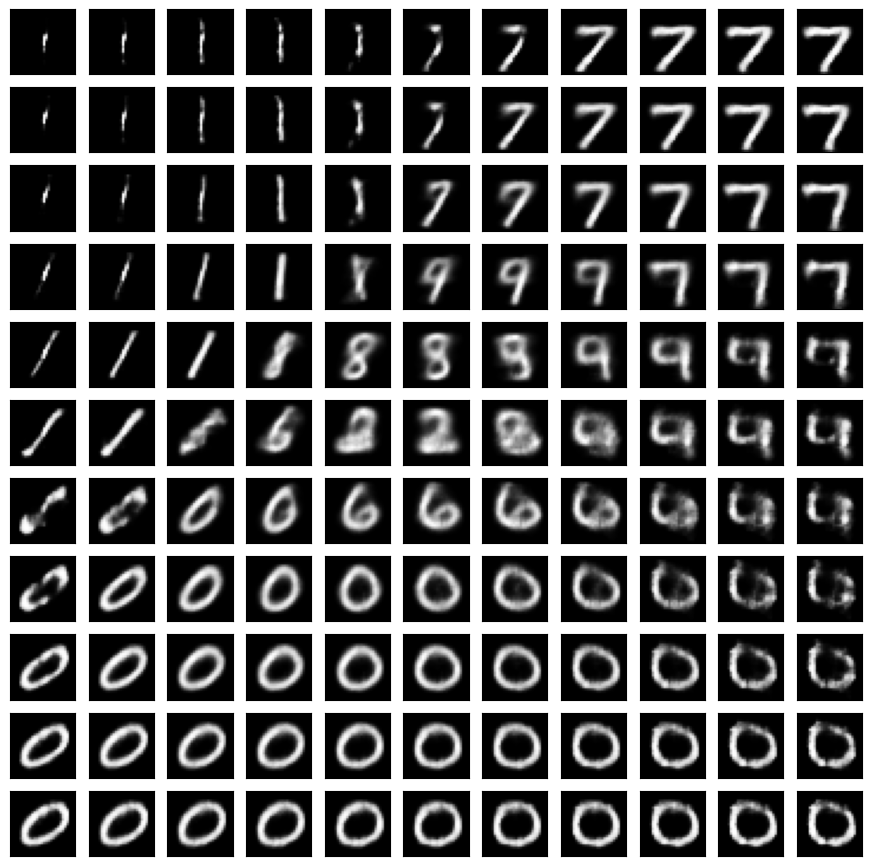

In [125]:
# Выведем 100 цифр, сгенерированных декодером

showResult(vae.decoder)

**Содержание темы**

1. [Теория](https://colab.research.google.com/drive/12pLBd2_WMVgu3wxMmfjQRf2WxldDDJzm?usp=sharing)

2. Практика



